In [1]:
!pip install easyocr
import easyocr



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
from PIL import ImageFont, ImageDraw, Image
from glob import glob
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())

13.0
True


In [4]:
reader = easyocr.Reader(['fr','en'], gpu=True) # this needs to run only once to load the model into memory

base_image_path = r'../data/raw/images_tickets_caisse'
img_fns = glob(base_image_path + '/*')


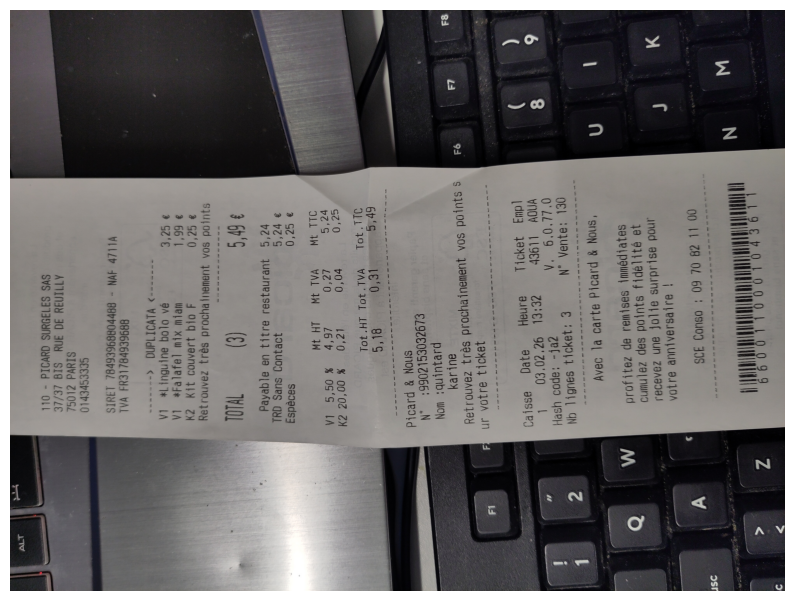

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(plt.imread(img_fns[0]))
ax.axis('off')
plt.show()

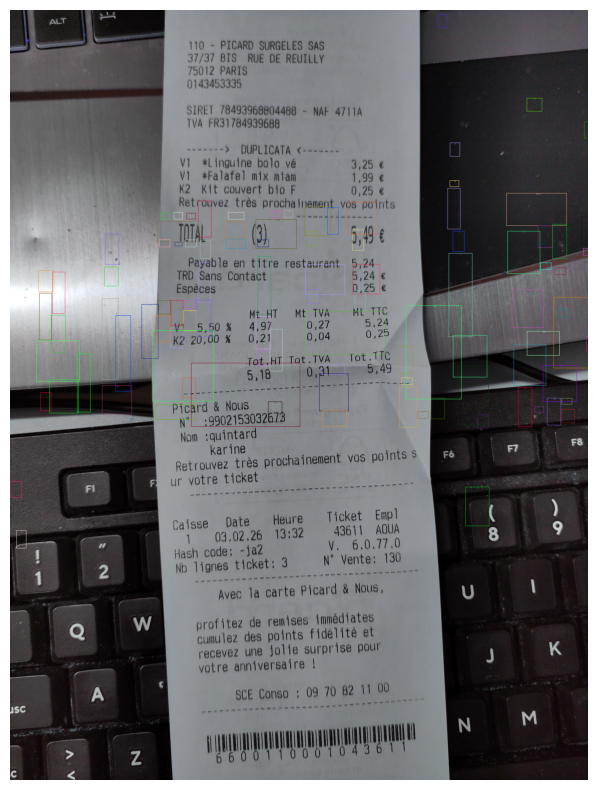

In [16]:
chosen_img = img_fns[0]
test_result = reader.readtext(plt.imread(chosen_img))
test_result

img    = cv2.imread(chosen_img)
img = Image.fromarray(img)
# font = ImageFont.truetype('/content/drive/MyDrive/Colab Notebooks/BMEULJIROTTF.ttf', 20)
draw = ImageDraw.Draw(img)
np.random.seed(42)
COLORS = np.random.randint(0, 255, size=(255, 3),dtype="uint8")
for i in test_result :
    x = i[0][0][0] 
    y = i[0][0][1] 
    w = i[0][1][0] - i[0][0][0] 
    h = i[0][2][1] - i[0][1][1]

    color_idx = random.randint(0,254) 
    color = [int(c) for c in COLORS[color_idx]]

    draw.rectangle(((x, y), (x+w, y+h)), outline=tuple(color), width=2)
    draw.text((int((x + x + w) / 2) , y-2),str(i[1]), fill=tuple(color),)

# plt.figure(figsize=(50,50))
# plt.imshow(img)
# plt.show()

fig, ax = plt.subplots(figsize=(10, 10))
ax.axis('off')
plt.imshow(img)
plt.show()